# 1,standard analysis of all cells

In [1]:
library(Seurat)
library(dplyr)
library(patchwork)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
vsx1.data <- Read10X(data.dir = "./filtered_feature_bc_matrix/")
vsx1 <- CreateSeuratObject(counts = vsx1.data, project = "spinal_vsx1")
vsx1

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


An object of class Seurat 
27597 features across 11000 samples within 1 assay 
Active assay: RNA (27597 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


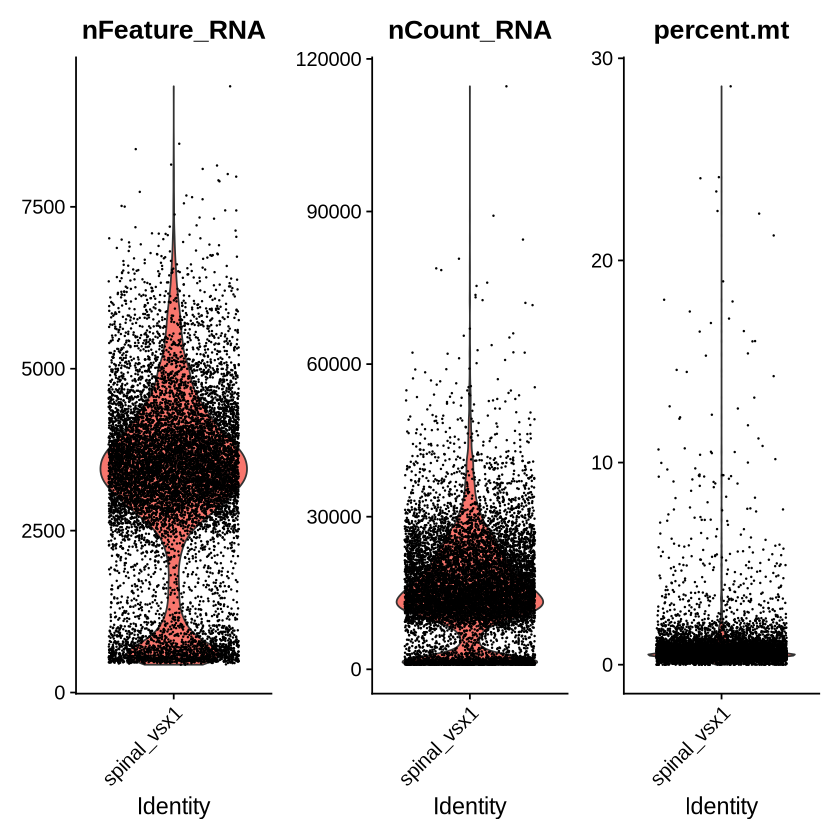

In [3]:
vsx1[["percent.mt"]] <- PercentageFeatureSet(vsx1, pattern = "^mt-")
VlnPlot(vsx1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

An object of class Seurat 
27597 features across 8956 samples within 1 assay 
Active assay: RNA (27597 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


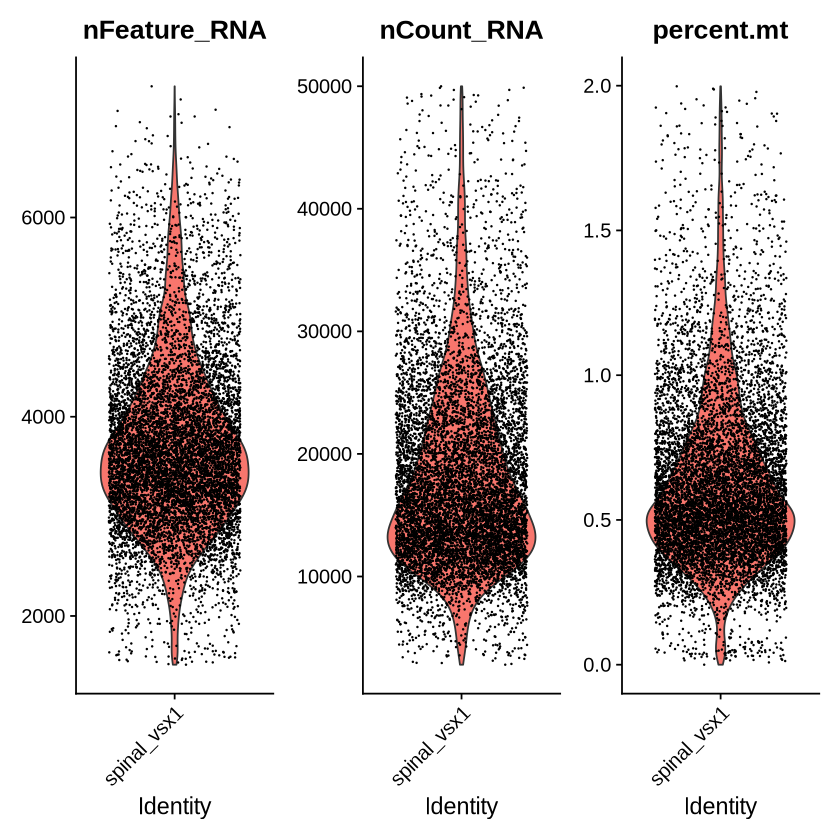

In [4]:
vsx1 <- subset(vsx1, subset = nFeature_RNA > 1500 & nFeature_RNA < 7500)
vsx1 <- subset(vsx1, subset = nCount_RNA > 100 & nCount_RNA < 50000 & percent.mt < 2)
vsx1
VlnPlot(vsx1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [ ]:
vsx1 <- NormalizeData(vsx1, normalization.method = "LogNormalize", scale.factor = 10000)
vsx1 <- FindVariableFeatures(vsx1, selection.method = "vst", nfeatures = 4000)
vsx1 <- ScaleData(object = vsx1)
vsx1 <- RunPCA(vsx1, features = VariableFeatures(object = vsx1))
vsx1 <- JackStraw(vsx1, num.replicate = 50)
vsx1 <- ScoreJackStraw(vsx1, dims = 1:20)
ElbowPlot(vsx1)

In [ ]:
vsx1 <- FindNeighbors(vsx1, dims = 1:15)
vsx1 <- FindClusters(vsx1, resolution = 0.5)
vsx1 <- RunUMAP(vsx1, dims = 1:15)

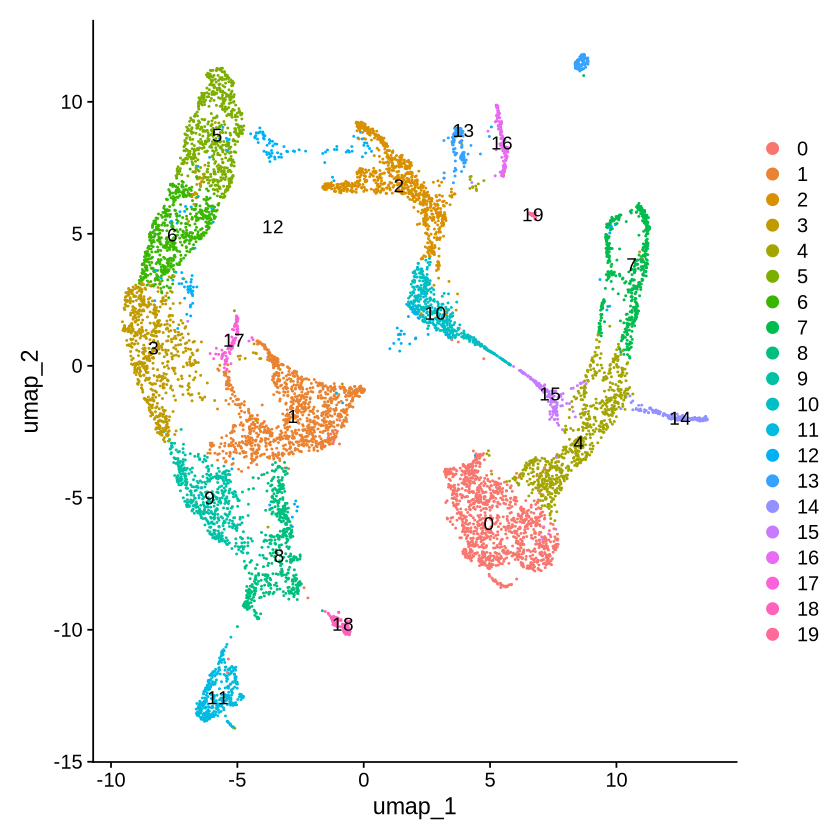

In [6]:
DimPlot(vsx1, reduction = "umap", label = TRUE)

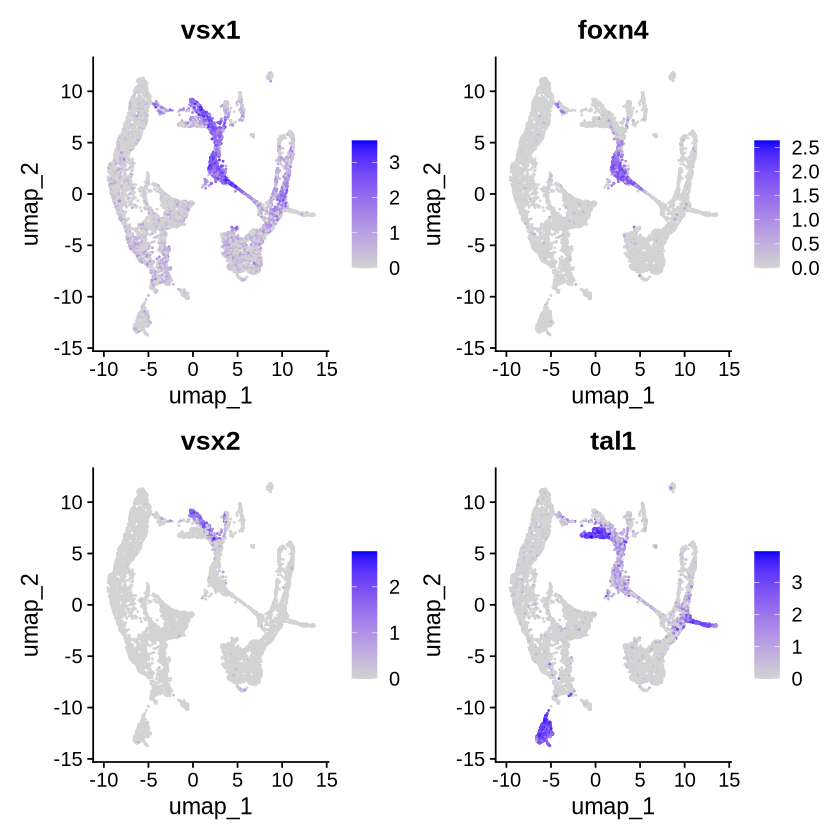

In [11]:
FeaturePlot(vsx1, features = c("vsx1", "foxn4", "vsx2", "tal1"))

In [ ]:
saveRDS(vsx1, file = "spinal_vsx1_batch2.rds")
#vsx1 <- readRDS(file = "spinal_vsx1_batch2.rds")
#rm(vsx1)

# extract v2a-v2b lineage cells

In [ ]:
v2av2b_raw <- subset(vsx1, idents = c( "2", "10"))
v2av2b_raw

An object of class Seurat 
27597 features across 1268 samples within 1 assay 
Active assay: RNA (27597 features, 4000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
v2av2b_raw <- NormalizeData(v2av2b_raw)
v2av2b_raw <- FindVariableFeatures(v2av2b_raw, selection.method = "vst", nfeatures = 4000)
v2av2b_raw <- ScaleData(v2av2b_raw)
v2av2b_raw <- RunPCA(v2av2b_raw, features = VariableFeatures(object = v2av2b_raw))

Warning message:
“Removed 20130 rows containing missing values or values outside the scale range
(`geom_point()`).”


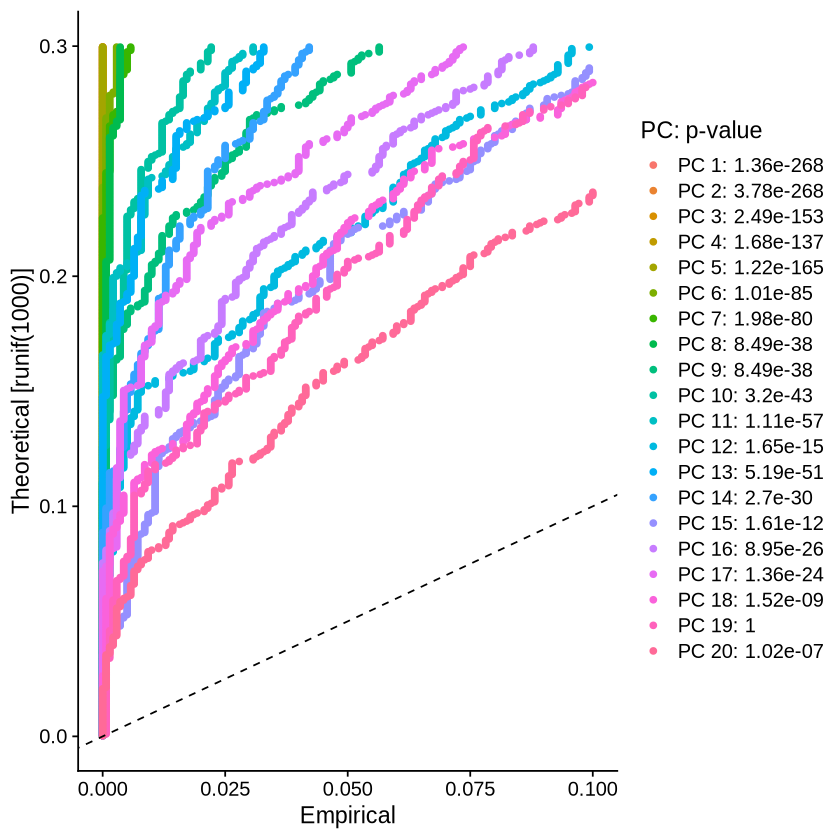

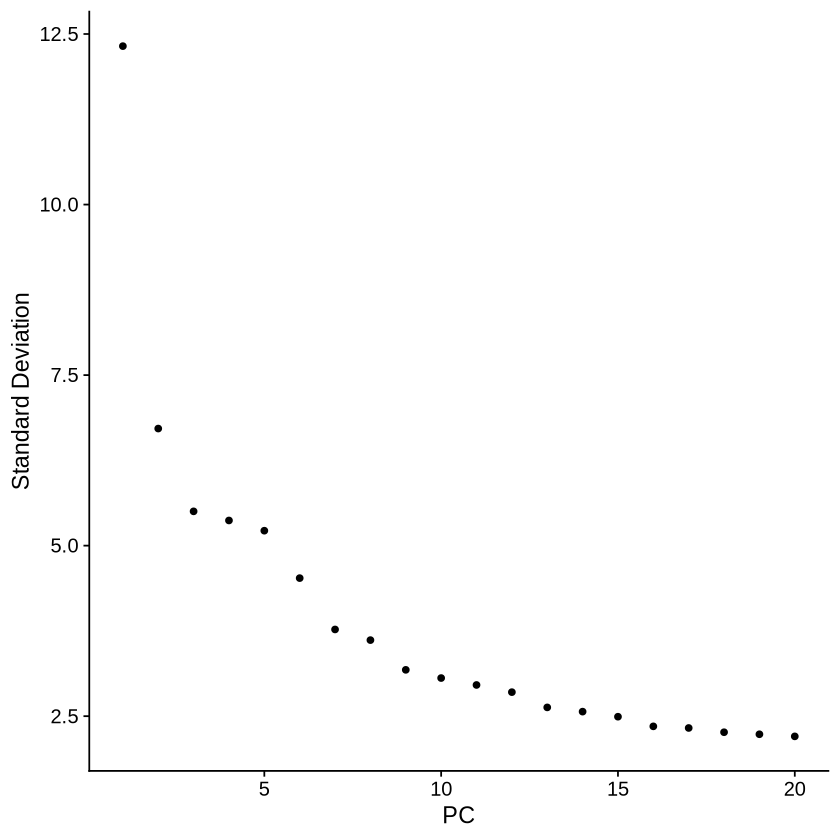

In [ ]:
v2av2b_raw <- JackStraw(v2av2b_raw, num.replicate = 100)
v2av2b_raw <- ScoreJackStraw(v2av2b_raw, dims = 1:20)
JackStrawPlot(v2av2b_raw, dims = 1:20)

In [ ]:
v2av2b_raw <- FindNeighbors(v2av2b_raw, dims = 1:10)
v2av2b_raw <- FindClusters(v2av2b_raw, resolution = 0.6)
v2av2b_raw <- RunUMAP(v2av2b_raw, dims = 1:10)

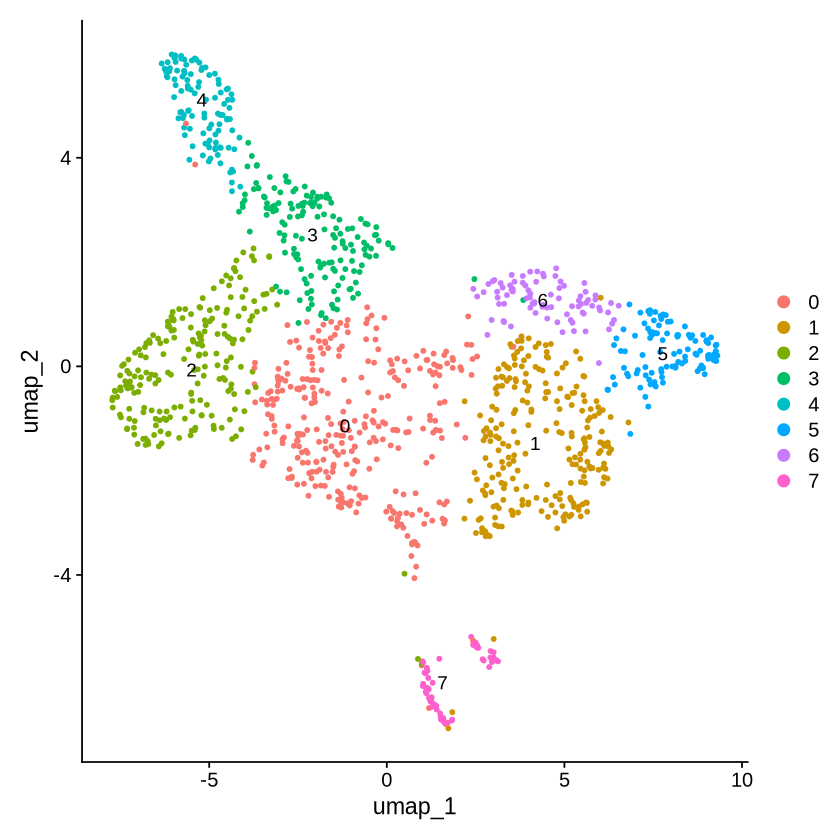

In [24]:
DimPlot(v2av2b_raw, reduction = "umap", label = TRUE)

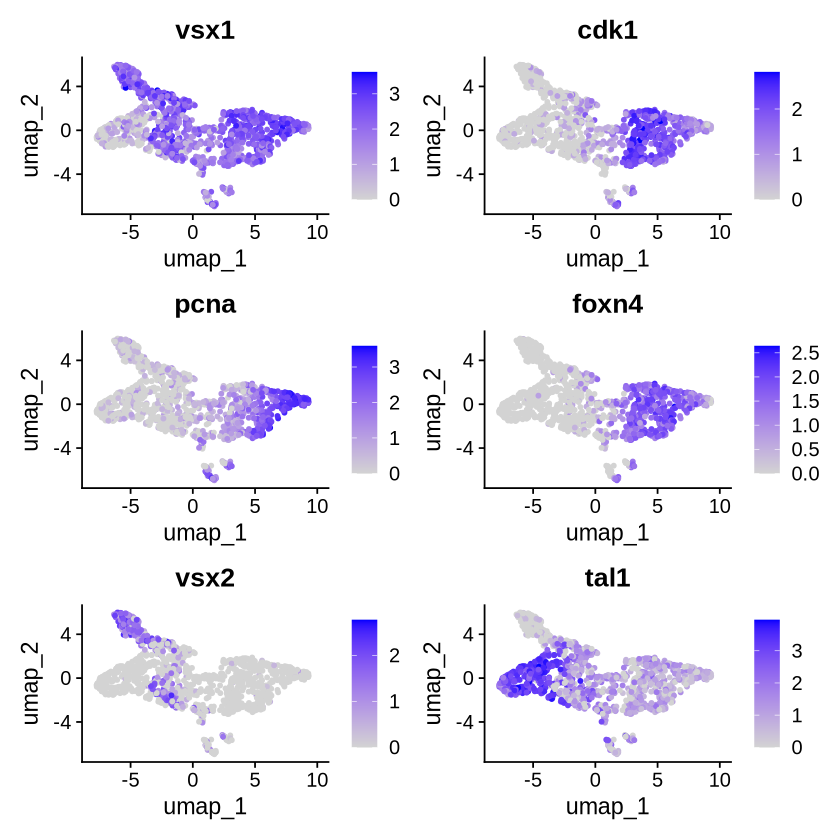

In [25]:
FeaturePlot(v2av2b_raw, features = c("vsx1", "cdk1", "pcna", "foxn4", "vsx2", "tal1"))

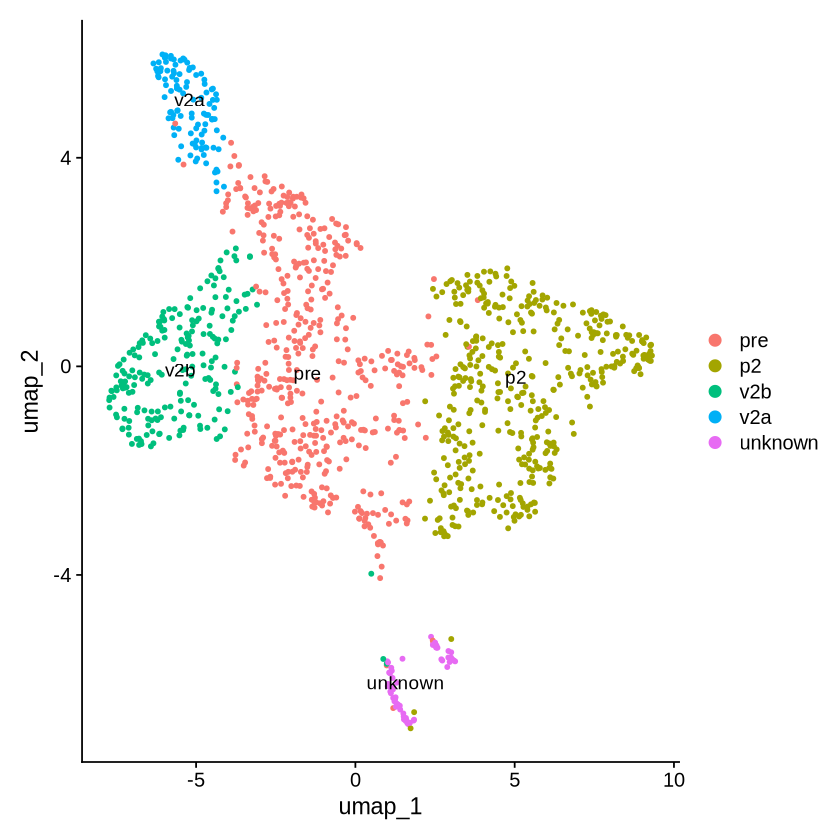

In [26]:
new.cluster.ids <- c("pre", "p2", "v2b", "pre", "v2a", "p2", "p2", "unknown" )
names(new.cluster.ids) <- levels(v2av2b_raw)
v2av2b_raw <- RenameIdents(v2av2b_raw, new.cluster.ids)
DimPlot(v2av2b_raw, reduction = "umap", label=T)

Warning message in DoHeatmap(v2av2b_raw, features = top10$gene):
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: CSRNP3, CU571064.1"


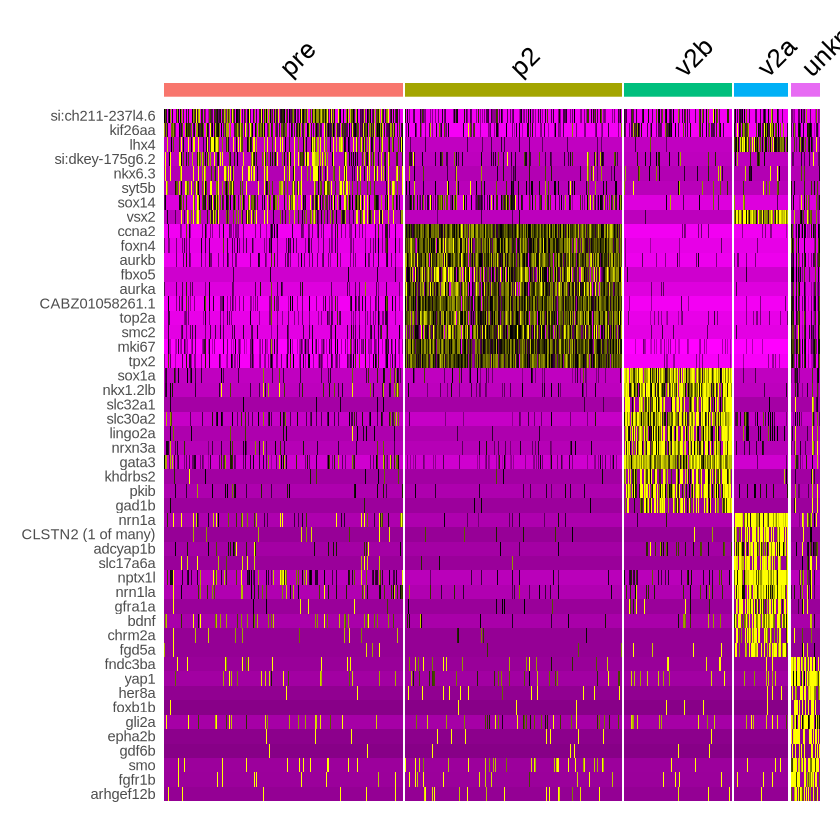

In [19]:
# find marker genes of different clusters
#v2av2b_markers <- FindAllMarkers(v2av2b_raw, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)
v2av2b_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10
DoHeatmap(v2av2b_raw, features = top10$gene) + NoLegend()



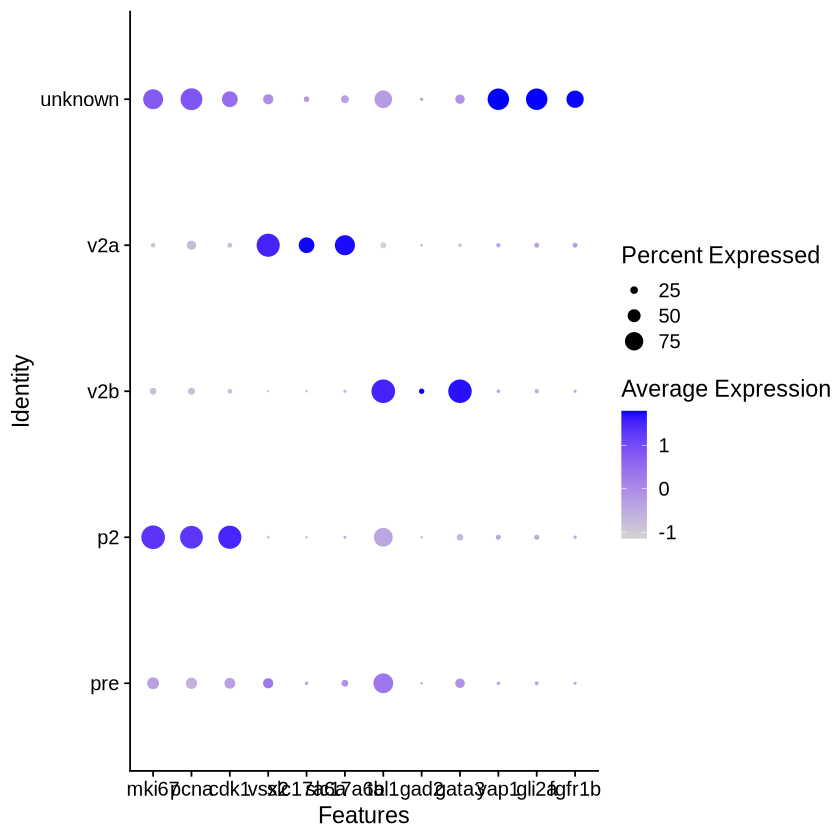

In [27]:
DotPlot(v2av2b_raw, features = c("mki67", "pcna", "cdk1", "vsx2", "slc17a6a", "slc17a6b", "tal1", "gad2", "gata3", "yap1", "gli2a", "fgfr1b"))

In [29]:
v2av2b_raw

An object of class Seurat 
27597 features across 1268 samples within 1 assay 
Active assay: RNA (27597 features, 4000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [2]:
#saveRDS( v2av2b_raw, file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_batch2.rds")
v2av2b <- readRDS( file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_batch2.rds")
#rm(v2av2b_raw)

In [2]:
v2av2b <- subset(v2av2b, idents = c( "pre", "p2", "v2b", "v2a"))
DimPlot(v2av2b, reduction = "umap", label=T)

ERROR: Error in DimPlot(v2av2b, reduction = "umap", label = T): could not find function "DimPlot"


Warning message:
"Scaling data with a low number of groups may produce misleading results"


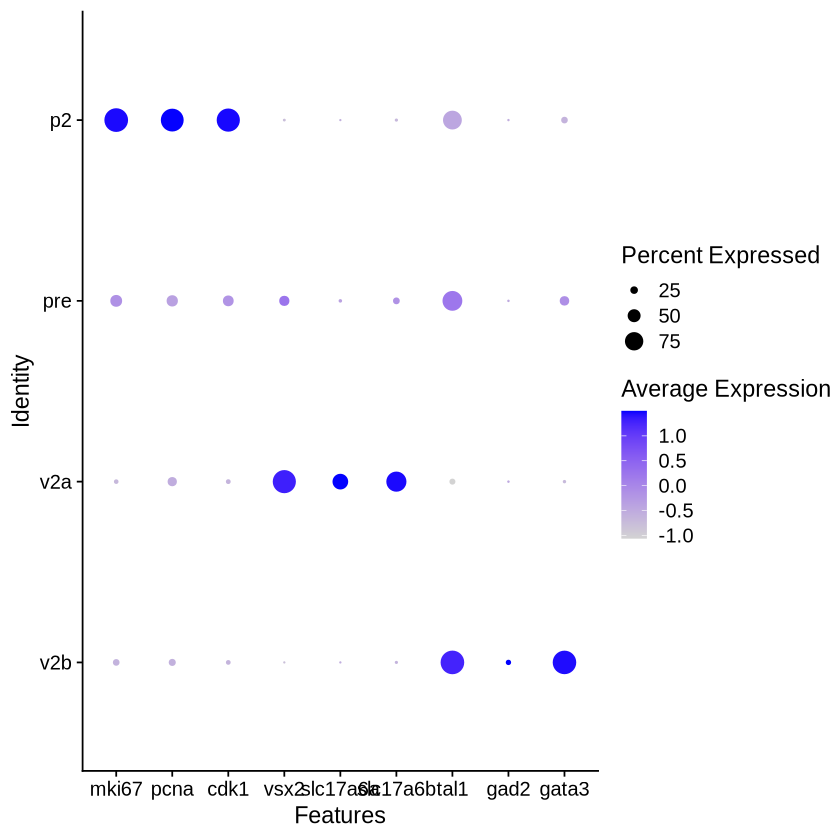

In [6]:
v2av2b@active.ident <- factor(
  v2av2b@active.ident,
  levels = c("v2b", "v2a", "pre", "p2")  # 按需调整顺序
)
DotPlot(v2av2b, features = c("mki67", "pcna", "cdk1", "vsx2", "slc17a6a", "slc17a6b", "tal1", "gad2", "gata3"))

Warning message:
“Scaling data with a low number of groups may produce misleading results”


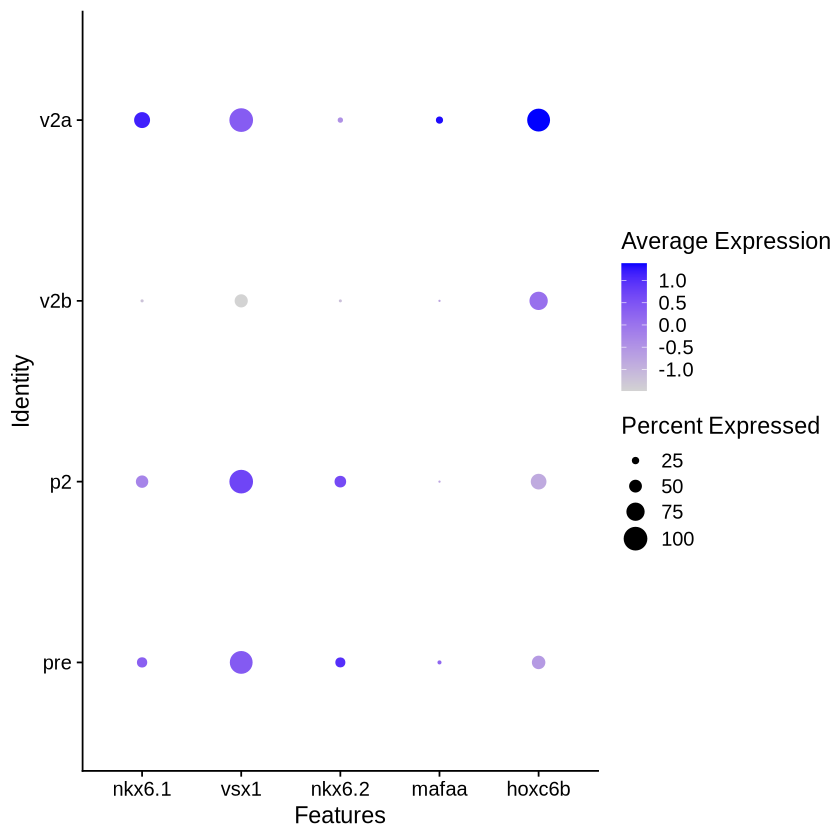

In [4]:

DotPlot(v2av2b, features = c( "nkx6.1", "vsx1", "nkx6.2", "mafaa", "hoxc6b"))


In [5]:
pdf("express-p2.pdf")
DotPlot(v2av2b, features = c( "nkx6.1", "vsx1", "nkx6.2", "mafaa", "hoxc6b"))
dev.off()

Warning message:
“Scaling data with a low number of groups may produce misleading results”


pdf 
  2

# dynamics of notch effector genes in v2a-v2b lineage progression

Warning message:
“Scaling data with a low number of groups may produce misleading results”


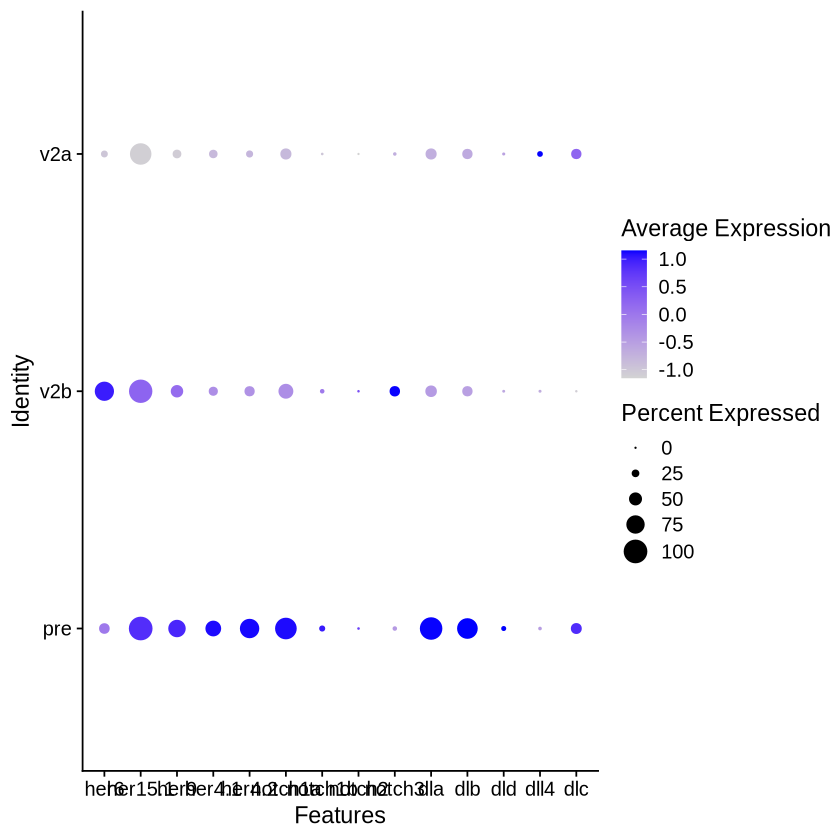

In [6]:
desired_cells <- subset(v2av2b, idents = c( "v2a", "v2b", "pre"))
notch.ligand <- c( "dla", "dlb",  "dld",  "dll4", "dlc")
notch.receptor <- c("notch1a", "notch1b", "notch2", "notch3")
notch.effector <- c( "her6", "her15.1", "her9", "her4.1", "her4.2" ) # v2b/v2a > 1.5
notch.gene <- c( "her6", "her15.1", "her9", "her4.1", "her4.2", "notch1a", "notch1b", "notch2", "notch3",  "dla", "dlb",  "dld",  "dll4", "dlc")
DotPlot(desired_cells, features = notch.gene)

In [12]:
pdf("notch_rna.pdf")
DotPlot(desired_cells, features = notch.gene)
dev.off()

Warning message:
"Scaling data with a low number of groups may produce misleading results"


pdf 
  2

In [24]:
norm.expr <- AverageExpression(desired_cells, features = notch.ligand)$RNA
head(norm.expr)



5 x 3 sparse Matrix of class "dgCMatrix"
            pre         v2b        v2a
dlb  3.86090329 0.568482733 0.44206278
dla  7.16499545 1.249992490 0.83257893
dll4 0.06174443 0.050723465 0.16053248
dld  0.11043485 0.021360551 0.02464933
dlc  0.54400999 0.007333336 0.33821661

In [25]:
norm.expr <- cbind(norm.expr, norm.expr[,3] / (norm.expr[,2]+0.05))
norm.expr <- norm.expr[order(norm.expr[,4], decreasing = TRUE),]
norm.expr

5 x 4 sparse Matrix of class "dgCMatrix"
            pre         v2b        v2a          
dlc  0.54400999 0.007333336 0.33821661 5.8991266
dll4 0.06174443 0.050723465 0.16053248 1.5937943
dlb  3.86090329 0.568482733 0.44206278 0.7147536
dla  7.16499545 1.249992490 0.83257893 0.6404490
dld  0.11043485 0.021360551 0.02464933 0.3454195